# Filtered Company List EDA\n
\n
Reads `structured_csv_data_files/fetched_data/filtered_company_list.csv` and explores sectors/industries/market caps.

In [ ]:
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd().resolve().parent.parent  # notebooks/EDA -> repo root 
COMPANIES_CSV = REPO_ROOT / "structured_csv_data_files" / "fetched_data" / "filtered_company_list.csv"
COMPANIES_CSV

PosixPath('/Users/shaunaksoni/Cursor/ML Project/ml-weekend-gap-prediction/structured_csv_data_files/fetched_data/filtered_company_list.csv')

In [2]:
companies = pd.read_csv(COMPANIES_CSV)
companies.shape

(26, 7)

In [3]:
companies.head(10)

,Ticker,Exchange,Sector,Industry,MarketCap,ProfitMargin,TradingAge
0,CRM,NYQ,Technology,Software - Application,1.830711e+11,0.17958,22
1,PANW,NMS,Technology,Software - Infrastructure,1.329672e+11,0.12957,14
2,INTU,NMS,Technology,Software - Application,1.267705e+11,0.21570,33
3,NOW,NYQ,Technology,Software - Application,1.164667e+11,0.13165,14
4,ADBE,NMS,Technology,Software - Application,1.018656e+11,0.29477,40
5,ADP,NMS,Technology,Software - Application,8.440440e+10,0.19964,46
6,SNPS,NMS,Technology,Software - Infrastructure,8.051736e+10,0.13756,34
7,CDNS,NMS,Technology,Software - Application,7.832105e+10,0.20935,39
8,FTNT,NMS,Technology,Software - Infrastructure,6.053296e+10,0.27257,17
9,ADSK,NMS,Technology,Software - Application,5.257388e+10,0.15598,41


In [4]:
companies.dtypes.sort_index()

Exchange         object
Industry         object
MarketCap       float64
ProfitMargin    float64
Sector           object
Ticker           object
TradingAge        int64
dtype: object

In [ ]:
# Missingness 
companies.isna().mean().sort_values(ascending=False)

Ticker          0.0
Exchange        0.0
Sector          0.0
Industry        0.0
MarketCap       0.0
ProfitMargin    0.0
TradingAge      0.0
dtype: float64

In [ ]:
# Counts 
{
    "n_companies": len(companies),
    "n_sectors": companies["Sector"].nunique() if "Sector" in companies.columns else None,
    "n_industries": companies["Industry"].nunique() if "Industry" in companies.columns else None,
}

{'n_companies': 26, 'n_sectors': 1, 'n_industries': 2}

In [7]:
if "Sector" in companies.columns:
    display(companies["Sector"].value_counts())

Sector
Technology    26
Name: count, dtype: int64

In [8]:
if "Industry" in companies.columns:
    display(companies["Industry"].value_counts().head(30))

Industry
Software - Application       16
Software - Infrastructure    10
Name: count, dtype: int64

In [ ]:
# Market cap quick checks 
if "MarketCap" in companies.columns:
    mc = pd.to_numeric(companies["MarketCap"], errors="coerce")
    display(mc.describe())
    display(companies.assign(MarketCap_num=mc).sort_values("MarketCap_num", ascending=False).head(20))

count    2.600000e+01
mean     5.201579e+10
std      4.692254e+10
min      1.293254e+10
25%      1.665188e+10
50%      2.998600e+10
75%      7.996828e+10
max      1.830711e+11
Name: MarketCap, dtype: float64

,Ticker,Exchange,Sector,Industry,MarketCap,ProfitMargin,TradingAge,MarketCap_num
0,CRM,NYQ,Technology,Software - Application,1.830711e+11,0.17958,22,1.830711e+11
1,PANW,NMS,Technology,Software - Infrastructure,1.329672e+11,0.12957,14,1.329672e+11
2,INTU,NMS,Technology,Software - Application,1.267705e+11,0.21570,33,1.267705e+11
3,NOW,NYQ,Technology,Software - Application,1.164667e+11,0.13165,14,1.164667e+11
4,ADBE,NMS,Technology,Software - Application,1.018656e+11,0.29477,40,1.018656e+11
5,ADP,NMS,Technology,Software - Application,8.440440e+10,0.19964,46,8.440440e+10
6,SNPS,NMS,Technology,Software - Infrastructure,8.051736e+10,0.13756,34,8.051736e+10
7,CDNS,NMS,Technology,Software - Application,7.832105e+10,0.20935,39,7.832105e+10
8,FTNT,NMS,Technology,Software - Infrastructure,6.053296e+10,0.27257,17,6.053296e+10
9,ADSK,NMS,Technology,Software - Application,5.257388e+10,0.15598,41,5.257388e+10


In [10]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

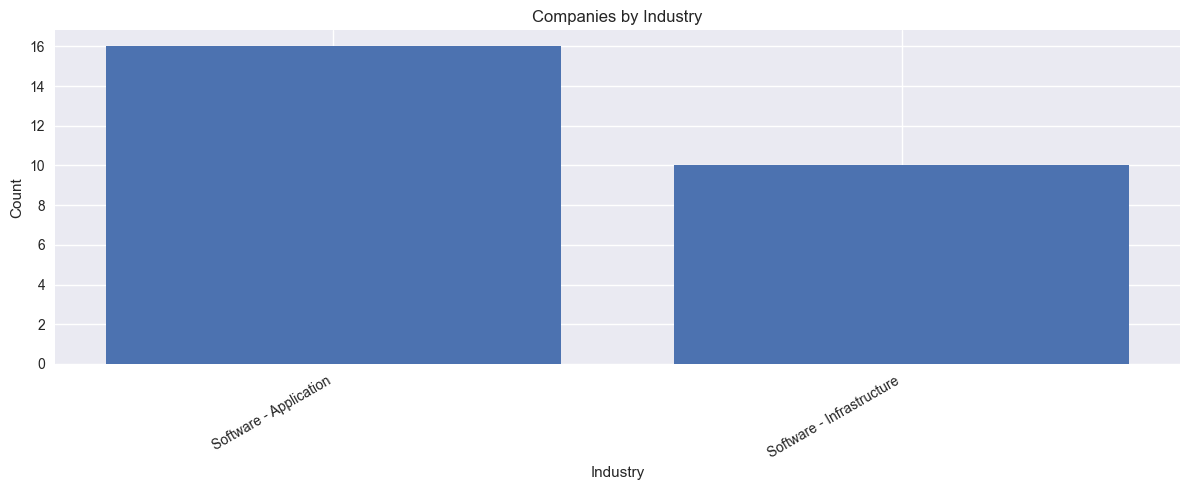

In [11]:
# Industry breakdown
if "Industry" in companies.columns:
    vc = companies["Industry"].value_counts()
    plt.bar(vc.index.astype(str), vc.values)
    plt.title("Companies by Industry")
    plt.xlabel("Industry")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

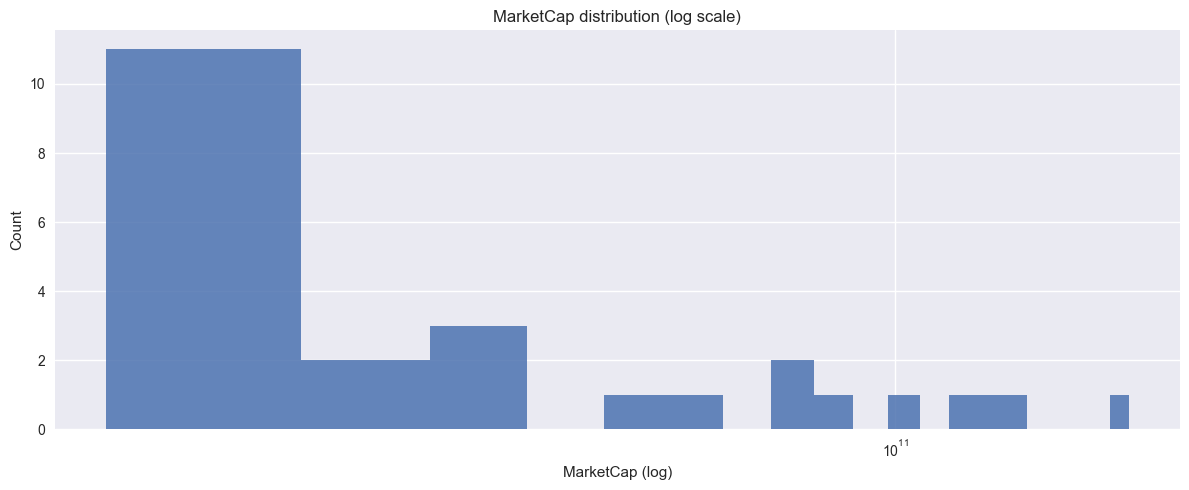

In [12]:
# MarketCap distribution (log scale)
if "MarketCap" in companies.columns:
    mc = pd.to_numeric(companies["MarketCap"], errors="coerce").dropna().clip(lower=1)
    plt.hist(mc, bins=20, alpha=0.85)
    plt.xscale("log")
    plt.title("MarketCap distribution (log scale)")
    plt.xlabel("MarketCap (log)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

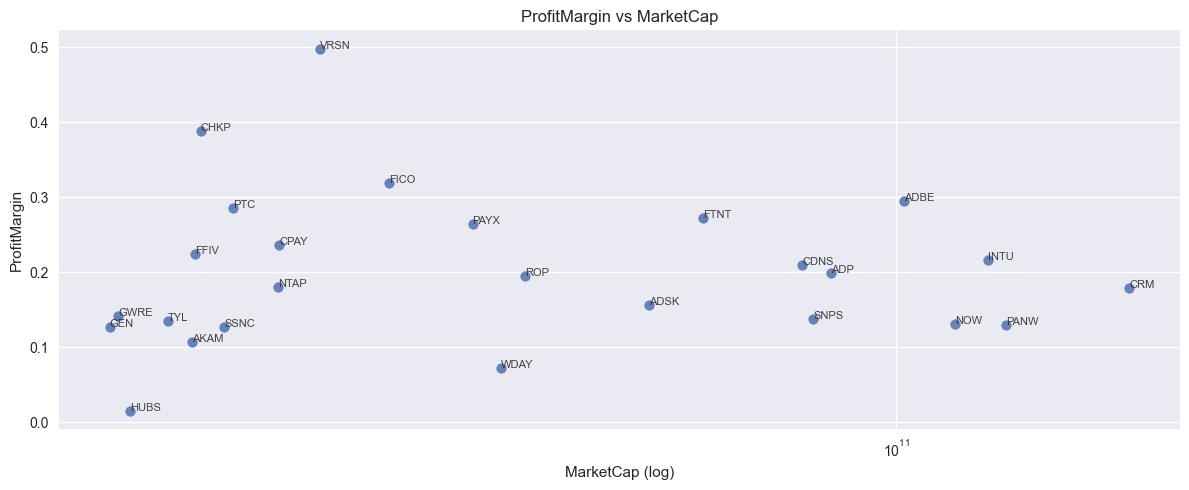

In [13]:
# ProfitMargin vs MarketCap (log-x)
if {"MarketCap", "ProfitMargin"}.issubset(companies.columns):
    mc = pd.to_numeric(companies["MarketCap"], errors="coerce")
    pm = pd.to_numeric(companies["ProfitMargin"], errors="coerce")
    tmp = companies.assign(MarketCap_num=mc, ProfitMargin_num=pm).dropna(subset=["MarketCap_num", "ProfitMargin_num"])

    plt.scatter(tmp["MarketCap_num"], tmp["ProfitMargin_num"], alpha=0.85)
    for _, r in tmp.iterrows():
        plt.annotate(r["Ticker"], (r["MarketCap_num"], r["ProfitMargin_num"]), fontsize=8, alpha=0.85)

    plt.xscale("log")
    plt.title("ProfitMargin vs MarketCap")
    plt.xlabel("MarketCap (log)")
    plt.ylabel("ProfitMargin")
    plt.tight_layout()
    plt.show()

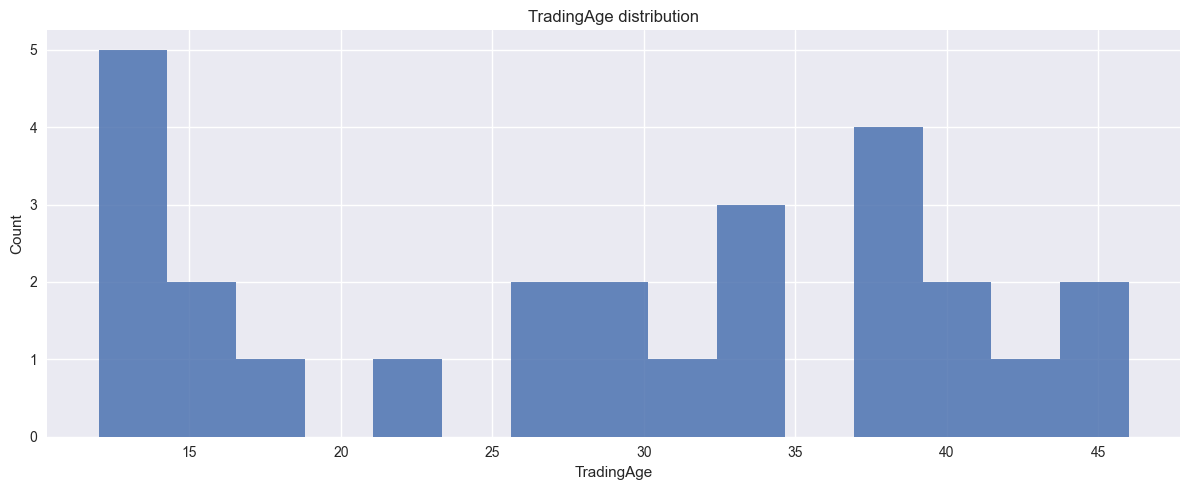

In [14]:
# TradingAge distribution
if "TradingAge" in companies.columns:
    ta = pd.to_numeric(companies["TradingAge"], errors="coerce").dropna()
    plt.hist(ta, bins=min(15, max(5, int(ta.nunique()))), alpha=0.85)
    plt.title("TradingAge distribution")
    plt.xlabel("TradingAge")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()